In [1]:
# Google Colab instructions
# Runtime > Change Runtime Type > Runtime Version > 2025.07
# This cell should say you're now on Python Version 3.11.

import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [2]:
!pip install pycaret openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 7.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyod to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 5.6 MB/s eta 0:00:00


In [1]:
# Before running: Runtime > Restart Session

from pycaret.classification import *

In [2]:
import pandas as pd

df = pd.read_excel("sipri_data1.xlsx")

#US Top Supplier Classification

In [9]:
classification_pipeline = setup(
    data=df,
    target='is_US_top_supplier_country?',
    session_id=42,
    train_size=0.8,
    normalize=True,
    ignore_features=['country', 'top_supplier_country', 'year'],
    numeric_imputation='mean',
    categorical_imputation='mode',
    fix_imbalance=True,
    fold=5
)

,Description,Value
0,Session id,42
1,Target,is_US_top_supplier_country?
2,Target type,Binary
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(226, 16)"
5,Transformed train set shape,"(190, 16)"
6,Transformed test set shape,"(36, 16)"
7,Ignore features,3
8,Numeric features,15
9,Rows with missing values,70.0%


In [10]:
# Compare all models

best_model1 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7367,0.7582,0.6378,0.6144,0.6185,0.4192,0.4260,0.1880
lightgbm,Light Gradient Boosting Machine,0.7293,0.7154,0.6356,0.5862,0.6067,0.4020,0.4052,0.1500
rf,Random Forest Classifier,0.6946,0.7456,0.6356,0.5694,0.5892,0.3513,0.3617,0.2380
gbc,Gradient Boosting Classifier,0.6877,0.7313,0.5756,0.5747,0.5598,0.3228,0.3331,0.1800
xgboost,Extreme Gradient Boosting,0.6810,0.7091,0.5533,0.5277,0.5375,0.2951,0.2973,0.0920
dt,Decision Tree Classifier,0.6603,0.6309,0.5356,0.5176,0.5175,0.2591,0.2645,0.0760
qda,Quadratic Discriminant Analysis,0.6601,0.7122,0.4267,0.5093,0.4556,0.2132,0.2195,0.0460
dummy,Dummy Classifier,0.6599,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0560
lr,Logistic Regression,0.6116,0.6673,0.6578,0.4566,0.5317,0.2220,0.2367,0.1000
lda,Linear Discriminant Analysis,0.6116,0.6793,0.6578,0.4516,0.5306,0.2198,0.2357,0.0460


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [12]:
et_model = create_model('et')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6552,0.5895,0.4000,0.5000,0.4444,0.1989,0.2015
1,0.8621,0.9053,0.7000,0.8750,0.7778,0.6796,0.6885
2,0.5517,0.6526,0.4000,0.3636,0.3810,0.0308,0.0309
3,0.7931,0.8132,0.8000,0.6667,0.7273,0.5628,0.5689
4,0.8214,0.8304,0.8889,0.6667,0.7619,0.6237,0.6402
Mean,0.7367,0.7582,0.6378,0.6144,0.6185,0.4192,0.4260
Std,0.1157,0.1179,0.2031,0.1728,0.1700,0.2567,0.2614


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [15]:
# Hyperparameter tuning

tuned_model1 = tune_model(et_model, optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4483,0.5684,0.6000,0.3333,0.4286,-0.0265,-0.0309
1,0.7241,0.8158,0.5000,0.6250,0.5556,0.3591,0.3638
2,0.6552,0.7632,0.6000,0.5000,0.5455,0.2714,0.2743
3,0.7586,0.8737,0.8000,0.6154,0.6957,0.5012,0.5131
4,0.6071,0.8304,0.8889,0.4444,0.5926,0.2870,0.3534
Mean,0.6387,0.7703,0.6778,0.5036,0.5636,0.2784,0.2947
Std,0.1088,0.1069,0.1437,0.1093,0.0859,0.1728,0.1802


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


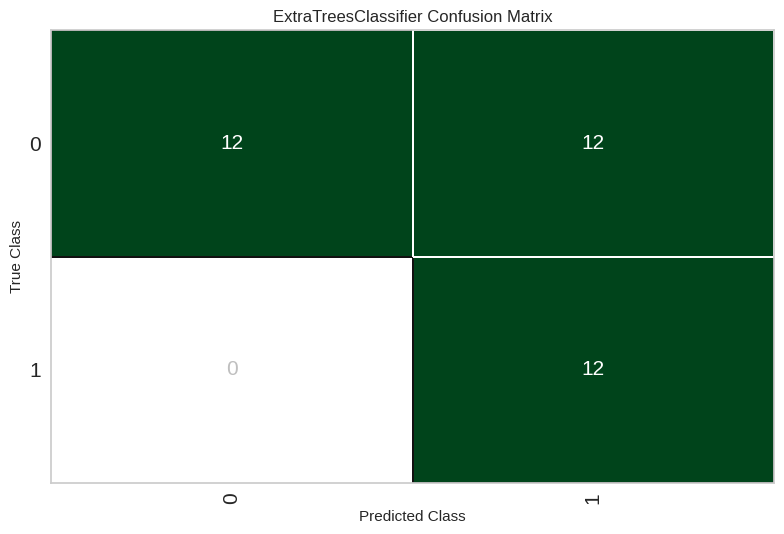

In [18]:
# Confusion Matrix

plot_model(tuned_model1, plot='confusion_matrix')

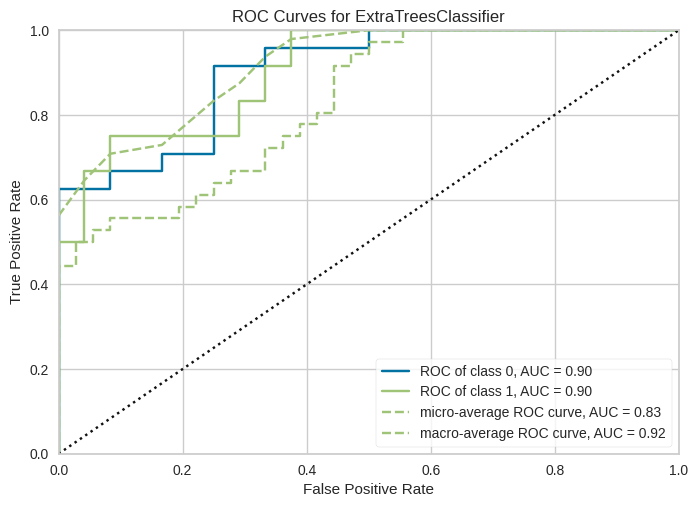

In [19]:
# ROC Curve

plot_model(tuned_model1, plot='auc')

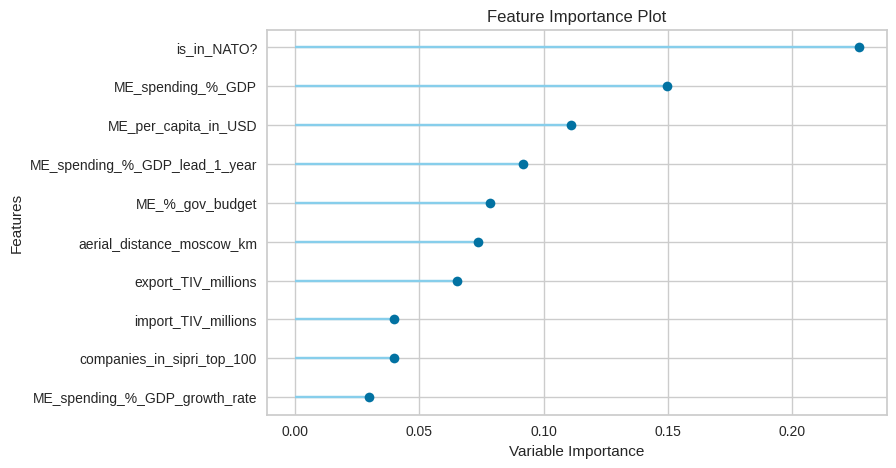

In [21]:
# Features that matter most

plot_model(tuned_model1, plot='feature')

In [22]:
# Interactive Evaluation Interface Dashboard

evaluate_model(tuned_model1)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#NATO Classification

In [29]:
classification_pipeline2 = setup(
    data=df,
    target='is_in_NATO?',
    session_id=42,
    train_size=0.8,
    normalize=True,
    ignore_features=['country', 'year'],   # trying to prevent leakage
    numeric_imputation='mean',
    categorical_imputation='mode',
    fix_imbalance=True,
    fold=5
)

,Description,Value
0,Session id,42
1,Target,is_in_NATO?
2,Target type,Binary
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(224, 40)"
5,Transformed train set shape,"(188, 40)"
6,Transformed test set shape,"(36, 40)"
7,Ignore features,2
8,Numeric features,15
9,Categorical features,1


In [30]:
# Compare all models

best_model2 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9239,0.9524,0.9368,0.9470,0.9401,0.8354,0.8406,0.1460
ada,Ada Boost Classifier,0.8889,0.9553,0.9041,0.9275,0.9145,0.7553,0.7598,0.4240
gbc,Gradient Boosting Classifier,0.8825,0.9766,0.8737,0.9427,0.9028,0.7555,0.7668,0.2920
et,Extra Trees Classifier,0.8815,0.8944,0.9035,0.9176,0.9081,0.7403,0.7492,0.2280
lightgbm,Light Gradient Boosting Machine,0.8480,0.9301,0.8632,0.9017,0.8796,0.6732,0.6796,0.2240
rf,Random Forest Classifier,0.8475,0.9390,0.8515,0.9106,0.8784,0.6740,0.6796,0.3180
dt,Decision Tree Classifier,0.8411,0.8316,0.8632,0.8917,0.8724,0.6598,0.6706,0.0900
knn,K Neighbors Classifier,0.7002,0.7439,0.7637,0.7691,0.7652,0.3473,0.3482,0.0840
lr,Logistic Regression,0.6798,0.6951,0.7123,0.7796,0.7408,0.3222,0.3294,0.0880
ridge,Ridge Classifier,0.6732,0.6893,0.7439,0.7520,0.7469,0.2841,0.2865,0.0880


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [31]:
# Hyperparameter tuning

tuned_model2 = tune_model(best_model2, optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8276,0.8789,0.8947,0.8500,0.8718,0.6092,0.6110
1,0.8276,0.9684,1.0000,0.7917,0.8837,0.5672,0.6292
2,0.8276,0.9474,0.9474,0.8182,0.8780,0.5892,0.6080
3,0.8966,1.0000,1.0000,0.8636,0.9268,0.7535,0.7775
4,0.9286,0.9944,1.0000,0.9000,0.9474,0.8372,0.8485
Mean,0.8616,0.9578,0.9684,0.8447,0.9016,0.6713,0.6948
Std,0.0428,0.0437,0.0421,0.0373,0.0300,0.1056,0.0993


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


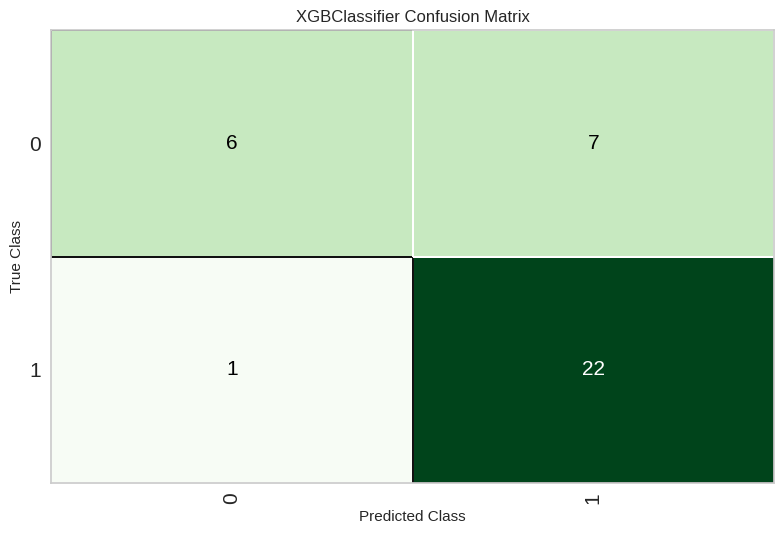

In [33]:
# Confusion Matrix

plot_model(tuned_model2, plot='confusion_matrix')

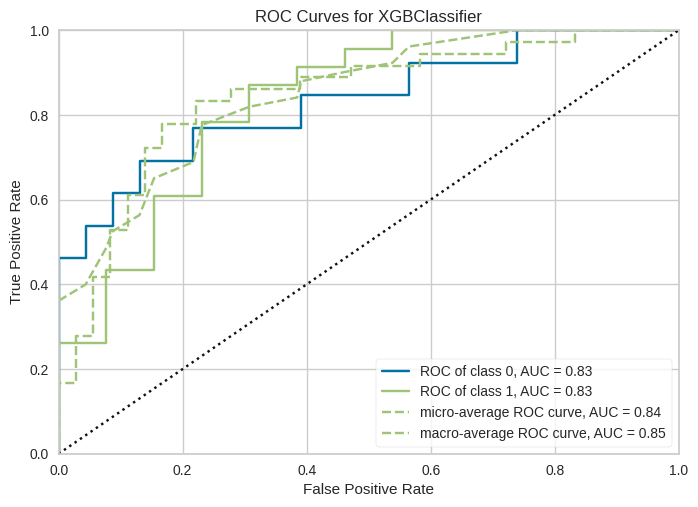

In [34]:
# ROC Curve

plot_model(tuned_model2, plot='auc')

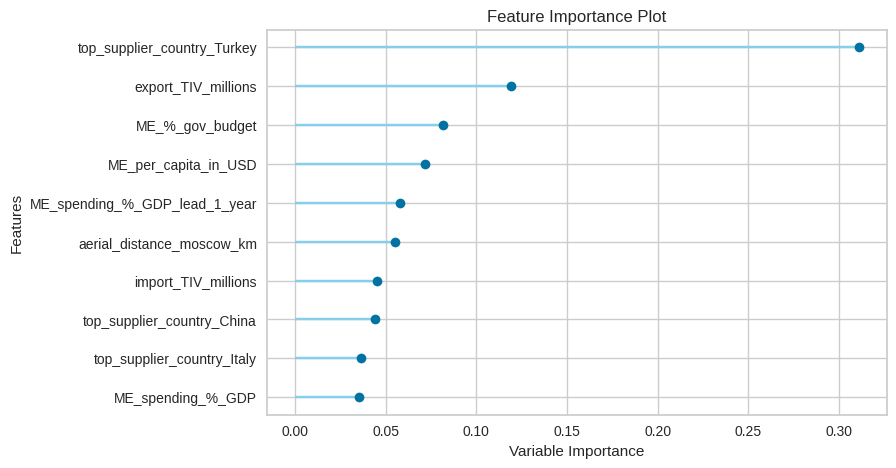

In [35]:
# Features that matter most

plot_model(tuned_model2, plot='feature')

In [38]:
# Interactive Evaluation Interface Dashboard

evaluate_model(tuned_model2)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…